In [2]:
%load_ext autoreload

%autoreload 2
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [3]:
from DFTStructureGenerator import DFThandle
import os, glob
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
import pickle
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
np.random.seed(0)

In [3]:
data_dir = "Data"
csv_dir = os.path.join(data_dir, "Iteration_2", "Result")
row_csv = "Data_clear.csv"
target_csv = "Data_clear_with_sites.csv"

In [4]:
with open(r"Data/DFT/all_fp_map.pkl", 'rb')as f:
    qm_dict, area_dict = pickle.load(f)

In [5]:
binol_3_3 = [ 2,  3,  4,  5,  6, 26, 27, 39, 35, 31, 42, 41, 40, 34, 32, 30, 28, 29, 44, 33, 37, 43, 36, 38]
binol_4_4 = [7, 8, 9]
binol_6_6 = [10, 11, 12, 13, 14, 15, 16, 17]
binol_7_7 = [18, 19, 20, 21, 22]
binol_other = [ 1, 23, 25, 24]
all_binol_split = [binol_3_3, binol_4_4, binol_6_6, binol_7_7, binol_other]

# Descriptors Correlations

In [ ]:
full_data_csv = DFThandle.read_reaction_csv("Data\Iteration_2\Full_Space_ActiveLearning.csv")
all_X = DFThandle.descriptor_to_array(full_data_csv, [qm_dict, area_dict])

In [18]:
def draw_correlation_map(X, figure_size=(5, 5), colors='coolwarm', useSVG=False, save_name='test', annot=True, show_label=False):
    # scaler = StandardScaler()
    # X = scaler.fit_transform(X)
    df = pd.DataFrame(X)
    correlation_matrix = np.abs(df.corr())
    # correlation_matrix = correlation_matrix.fillna(0)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    print(np.max(correlation_matrix.to_numpy()[~mask]))
    f, ax = plt.subplots(figsize=figure_size, dpi=300)
    annot_kws = {"fontsize": 10}
    ax = sns.heatmap(correlation_matrix, 
            mask=mask,
            cmap='coolwarm',    
            annot=annot,         
            fmt='.1f',          
            center=0,           
            cbar=1,
            annot_kws=annot_kws,)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    if not show_label:
        ax.set_xticklabels('', fontsize=10)
        ax.set_yticklabels('', fontsize=10)
    plt.tight_layout()
    return correlation_matrix

In [8]:
def remove_high_corr(All_X, threshold=0.9):
    _, idx = np.unique(All_X, axis=1, return_index=True)
    idx = np.sort(idx)
    All_X = All_X[:, idx]
    corr_matrix = np.corrcoef(All_X, rowvar=False)
    to_drop = set([38])
    for i in range(corr_matrix.shape[0]):
        for j in range(i + 1, corr_matrix.shape[0]):
            if abs(corr_matrix[i, j]) > threshold:
                to_drop.add(j)
    keep = [idx for idx in range(All_X.shape[1]) if idx not in to_drop]
    return All_X[:, keep], keep

In [15]:
new_all_X, keep = remove_high_corr(all_X)
all_X.shape, new_all_X.shape


((7832, 167), (7832, 128))

In [24]:
np.array(keep)

array([  0,   1,   3,   7,   8,   9,  11,  13,  14,  16,  18,  19,  21,
        23,  25,  27,  28,  29,  30,  33,  35,  37,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 112, 113, 115, 116, 117, 118, 119, 120, 121, 129,
       130, 132, 133, 134, 136, 138, 139, 140, 142, 143, 144, 146, 151,
       153, 154, 155, 156, 157, 158, 161, 162, 163, 164, 165])

0.8983820447583013


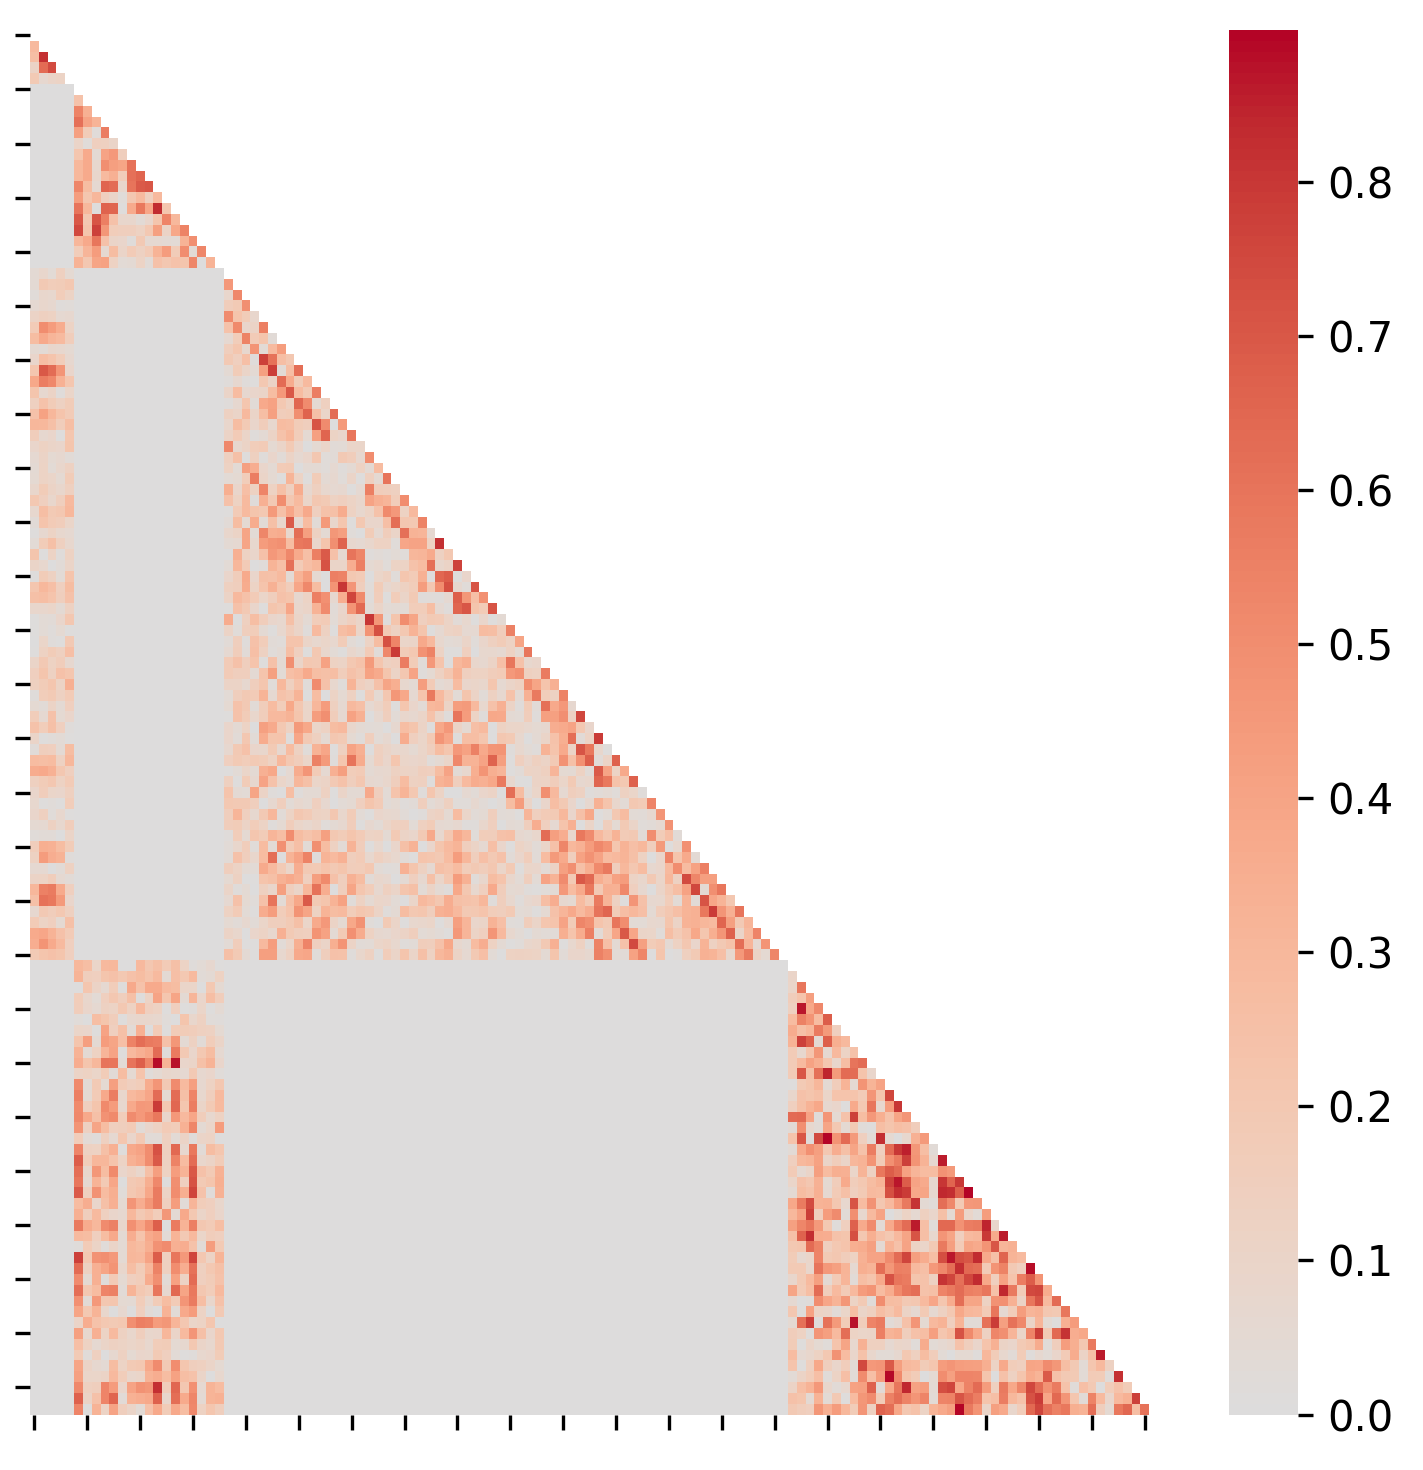

In [19]:
all_X = new_all_X
correlation_matrix = draw_correlation_map(all_X, figure_size=(5, 5), colors='coolwarm', useSVG=False, save_name='test', annot=False, show_label=False)

In [ ]:
# data_csv = read_reaction_csv("Data/Result/BINOL_result_sum_0015.csv")
final_all_r2s, final_mae, final_pred = [], [], []
all_r2_split = [[] for _ in range(len(all_binol_split))]
for idx, data_csv in enumerate([DFThandle.read_reaction_csv(each) for each in glob.glob(f"{csv_dir}/BINOL_result_sum_*.csv")]):
    y = data_csv['R'].to_numpy() - data_csv["S"].to_numpy()
    all_X = DFThandle.descriptor_to_array(data_csv, [qm_dict, area_dict], keep=des_keep_id)
    all_X = all_X[:, keep]
    target = y
    all_r2s = []
    all_mae = []
    all_pred = np.array([0 for _ in range(len(all_X))])
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    kf = list(kf.split(all_X))
    for train_ids, test_ids in kf:
        model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
        train_X, train_Y = all_X[train_ids], target[train_ids]
        temp_train_X = DFThandle.get_reverse_result(train_X)
        temp_train_Y = train_Y * -1
        train_X_ = np.concatenate([train_X, temp_train_X])
        train_Y_ = np.append(train_Y, temp_train_Y)
        model.fit(train_X_, train_Y_)
        y_pred = model.predict(all_X[test_ids])
        r2s = r2_score(target[test_ids], y_pred)
        all_r2s.append(r2s)
        all_mae.append(mean_absolute_error(target[test_ids], y_pred))
        all_pred[test_ids] = y_pred
    for binol_split_id, binol_split in enumerate(all_binol_split):
        row_in_split = [id_ for id_, each in data_csv.iterrows() if each['Binol'] in binol_split]
        all_r2_split[binol_split_id].append(r2_score(target[row_in_split], all_pred[row_in_split]))
    print(f"Round: {idx + 1}, all_R2: {np.mean(all_r2s)}, all_MAE: {np.mean(all_mae)}")
    final_all_r2s.append(np.mean(all_r2s))
    final_mae.append(np.mean(all_mae))
    final_pred.append(all_pred)

Round: 1, all_R2: -0.3182205628451824, all_MAE: 5.197604413658118
Round: 2, all_R2: 0.5870334313083555, all_MAE: 8.211362363068933
Round: 3, all_R2: 0.5843003904004835, all_MAE: 7.458207587393128
Round: 4, all_R2: 0.6900503007238121, all_MAE: 8.868892115660845
Round: 5, all_R2: 0.7532174819955308, all_MAE: 8.989978168841295
Round: 6, all_R2: 0.8078414043223328, all_MAE: 9.251524895442609
Round: 7, all_R2: 0.8036848483870012, all_MAE: 9.613033022838712
Round: 8, all_R2: 0.8024149047880351, all_MAE: 10.753315680376009
Round: 9, all_R2: 0.7922836999055, all_MAE: 11.678913773641524
Round: 10, all_R2: 0.8075336308490455, all_MAE: 11.823331668464323
Round: 11, all_R2: 0.8414713105185069, all_MAE: 11.350844984266619
Round: 12, all_R2: 0.8473954595110383, all_MAE: 11.532032209870247
Round: 13, all_R2: 0.8510319686897404, all_MAE: 11.13497214811292
Round: 14, all_R2: 0.8509079679702539, all_MAE: 11.34127246889786
Round: 15, all_R2: 0.8463793139834618, all_MAE: 11.467945133697535


# Model Importance

In [6]:
des_keep_id = [  0,   1,   3,   7,   8,   9,  11,  13,  14,  16,  18,  19,  21,
        23,  25,  27,  28,  29,  30,  33,  35,  37,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,
        69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,
        82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 112, 113, 115, 116, 117, 118, 119, 120, 121, 129,
       130, 132, 133, 134, 136, 138, 139, 140, 142, 143, 144, 146, 151,
       153, 154, 155, 156, 157, 158, 161, 162, 163, 164, 165]

In [ ]:
Final_df = pd.read_csv(f"{csv_dir}/BINOL_result_sum_0014.csv")
all_X = DFThandle.descriptor_to_array(Final_df,[qm_dict, area_dict], keep=des_keep_id)
model = CatBoostRegressor(iterations=10000, learning_rate=0.01, depth=6, verbose=0, random_state = 0)
y = Final_df['R'].to_numpy() - Final_df["S"].to_numpy()
model.fit(all_X, y)
importance = model.feature_importances_

In [34]:
BINOL_PhysOrg_name_list = ['BINOL_MaxBond a-b/e-f',
       'BINOL_MinBond a-b/e-f', 'BINOL_MaxBond b-c/d-e',
       'BINOL_MinBond b-c/d-e', 'BINOL_Bond c-d',
       'BINOL_MaxAngle a-b-c/d-e-f', 'BINOL_MinAngle a-b-c/d-e-f',
       'BINOL_MaxAngle b-c-d/c-d-e', 'BINOL_MinAngle b-c-d/c-d-e',
       'BINOL_Dihedral Angle b-c-d-e', 'BINOL_MaxBV 3,3’',
       'BINOL_MinBV 3,3’', 'BINOL_MaxBV 4,4’', 'BINOL_MinBV 4,4’',
       'BINOL_MaxBV 6,6’', 'BINOL_MinBV 6,6’', 'BINOL_MaxBV 7,7’',
       'BINOL_MinBV 7,7’', 'BINOL_Charge a', 'BINOL_Charge b',
       'BINOL_Charge c', 'BINOL_Charge d', 'BINOL_Charge e',
       'BINOL_Charge f', 'BINOL_HOMO – 1', 'BINOL_HOMO', 'BINOL_LUMO',
       'BINOL_LUMO + 1', 'BINOL_Dipole', 'BINOL_AtomNum']
Ligand_PhysOrg_name_list = ['Ligand_MaxCharge', 'Ligand_MinCharge',
       'Ligand_HOMO – 1', 'Ligand_HOMO', 'Ligand_LUMO', 'Ligand_LUMO + 1',
       'Ligand_Dipole', 'Ligand_IsBox', 'Ligand_AtomNum']
points = [(x, y, z) for z in range(4) for y in range(4) for x in range(4)]
Binol_Grid_name_list = [f"Binol_Grid_x_{x}_y_{y}_z_{z}" for x, y, z in points]
Ligand_Grid_name_list = [f"Ligand_Grid_x_{x}_y_{y}_z_{z}" for x, y, z in points]
all_des_name_list = BINOL_PhysOrg_name_list + Ligand_PhysOrg_name_list + Binol_Grid_name_list + Ligand_Grid_name_list
all_des_name_keep = np.array(all_des_name_list)[des_keep_id]

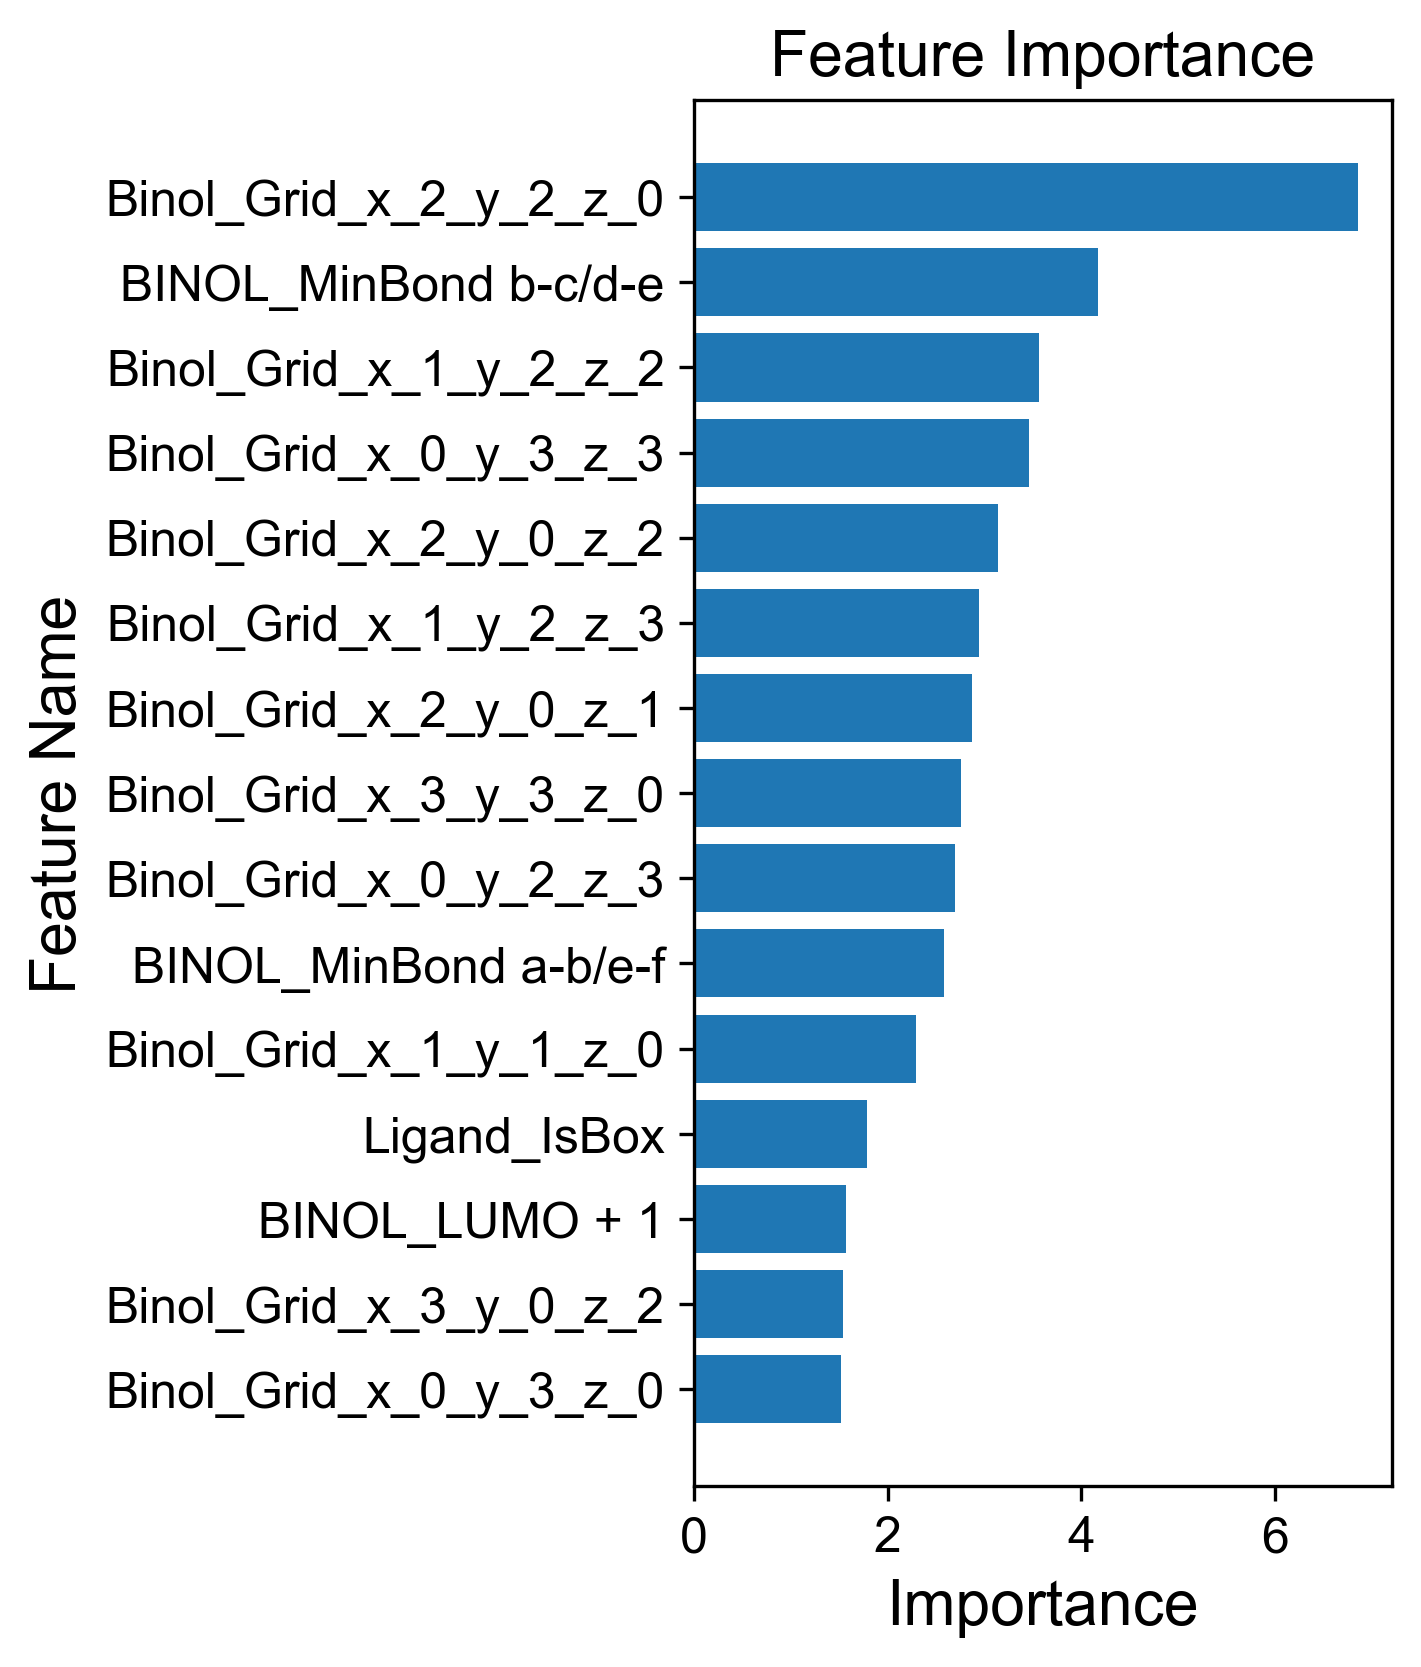

In [44]:
plt.figure(figsize=(3,6), dpi=300)
plt.barh(all_des_name_keep[np.argsort(importance)[-15:]], np.sort(importance)[-15:])
plt.rcParams['font.family'] = 'Arial'
plt.title("Feature Importance", fontsize=15)
plt.xlabel("Importance", fontsize=15)
plt.ylabel("Feature Name", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.xticks(rotation=90)
plt.show()

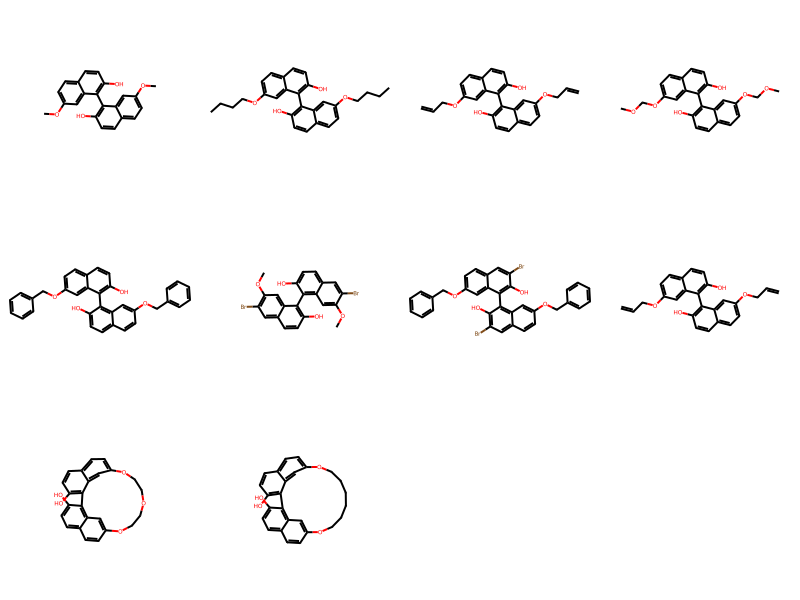

In [10]:
temp_df = pd.read_csv(r"ignored\backup\Data_clear_with_sites.csv")
temp_smiles = []
for row_id, row in temp_df.iterrows():
    mol = Chem.MolFromSmiles(row['Smiles'])
    if mol.HasSubstructMatch(Chem.MolFromSmiles("OC1=C(C2=C(C=CC=C3)C3=CC=C2O)C4=C(C=CC(OC)=C4)C=C1")):
        temp_smiles.append(row['Smiles'])
Chem.Draw.MolsToGridImage([Chem.MolFromSmiles(x) for x in temp_smiles], molsPerRow=4, subImgSize=(200, 200))